
<hr style="border:2px solid #2196F3;">

## 🧑‍💻 Lecture 02 - Exploratory Data Analysis (EDA)
<hr style="border:2px solid #2196F3;">

### 🔎Dataset: factory_production.csv
<b> This is a problem commonly faced by an industrial engineer. A manufacturing company operates two assembly lines (Line A and Line B), and management suspects that performance differs between them. This analysis will help guide decisions on process improvement, resource allocation and equipment maintenance.</b>

<b>⚠️ Upload the dataset factory_production.csv to the current file folder before running the next cell!!! </b>

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("factory_production.csv", header=0)

In [ ]:
# Quick overview
df.head()

,Date,Line,Shift,Units_Produced,Defect_Rate,Downtime_Minutes,Temperature_C,Humidity_%
0,2024-01-01,A,Morning,482,2.96,32,24.6,54
1,2024-01-01,A,Afternoon,508,2.73,58,23.8,61
2,2024-01-01,A,Night,481,4.20,30,26.8,58
3,2024-01-01,B,Morning,496,1.84,52,29.0,58
4,2024-01-01,B,Afternoon,438,1.77,74,30.0,51


In [ ]:
# Find the size of dataset
df.shape

(1080, 8)

In [ ]:
# Identify data types
df.dtypes

,0
Date,object
Line,object
Shift,object
Units_Produced,int64
Defect_Rate,float64
Downtime_Minutes,int64
Temperature_C,float64
Humidity_%,int64


In [ ]:
# Select some relevant columns
df1 = df[['Units_Produced','Defect_Rate']]
df1.head(5)

,Units_Produced,Defect_Rate
0,482,2.96
1,508,2.73
2,481,4.20
3,496,1.84
4,438,1.77


In [ ]:
# Check for missing values
print(df.isnull().sum())

Date                0
Line                0
Shift               0
Units_Produced      0
Defect_Rate         0
Downtime_Minutes    0
Temperature_C       0
Humidity_%          0
dtype: int64


In [ ]:
# univariate analysis
df.describe()

,Units_Produced,Defect_Rate,Downtime_Minutes,Temperature_C,Humidity_%
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,492.943519,2.952148,44.752778,26.941481,59.488889
std,33.731062,1.278716,12.462994,2.080440,4.839200
min,404.000000,1.170000,9.000000,19.700000,44.000000
25%,468.000000,1.990000,36.000000,25.500000,56.000000
50%,489.000000,2.470000,44.000000,26.900000,60.000000
75%,517.000000,3.600000,52.000000,28.400000,63.000000
max,598.000000,8.120000,89.000000,33.600000,77.000000


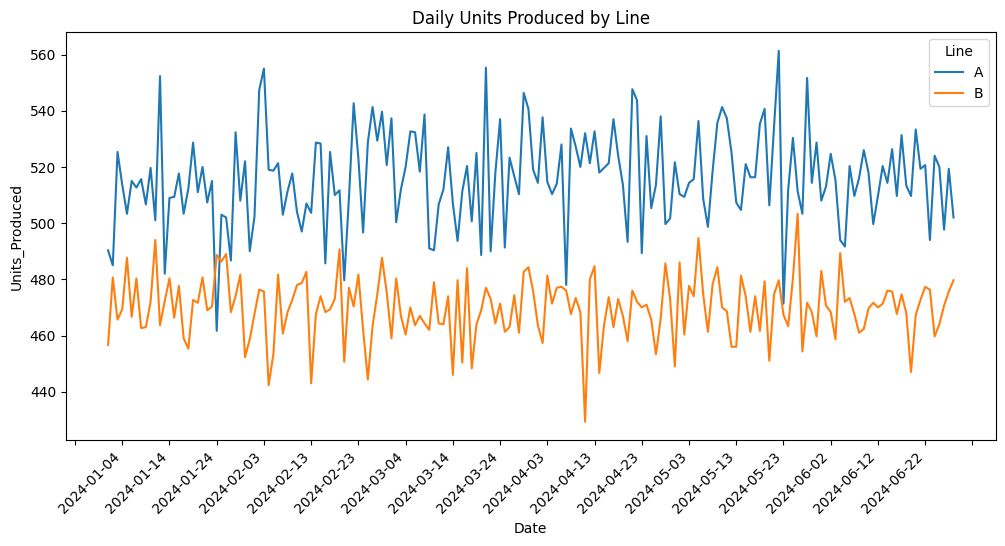

In [ ]:
# draw out the data to identify trend, pattern, correlation (if any)
import matplotlib.dates as mdates
# Production trend over time
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Date", y="Units_Produced", hue="Line", errorbar=None)

# Adjust the xticks frequency
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))
plt.gcf().autofmt_xdate()

plt.xticks(rotation=45)
plt.title("Daily Units Produced by Line")
plt.show()

## <b> Bivariate Analysis </b>

## <b>🎯Numeric vs Numeric </b>

Correlation between Temperature and Defect Rate: 0.14


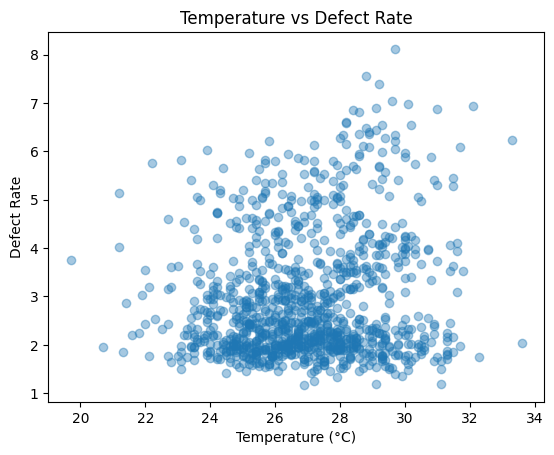

In [ ]:
# Correlation
corr = df['Temperature_C'].corr(df['Defect_Rate'])
print(f"Correlation between Temperature and Defect Rate: {corr:.2f}")

# Scatter plot
plt.scatter(df['Temperature_C'], df['Defect_Rate'], alpha=0.4)
plt.xlabel('Temperature (°C)')
plt.ylabel('Defect Rate')
plt.title('Temperature vs Defect Rate')
plt.show()

## <b>🎯Categorical vs Categorical </b>

Shift,Afternoon,Morning,Night
Line,,,
A,180,180,180
B,180,180,180


Chi-square statistic: 0.00
Degrees of freedom: 2
p-value: 1.0000


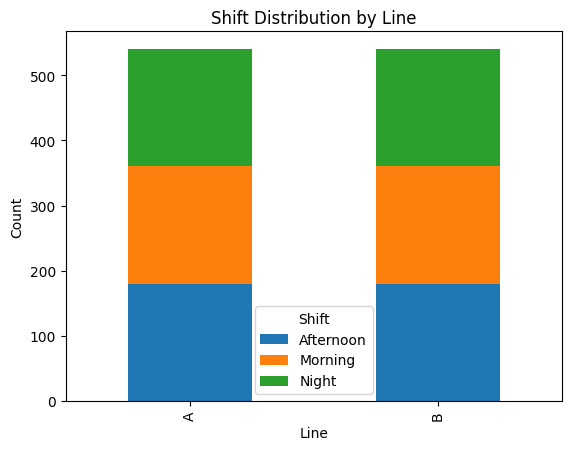

In [ ]:
# Contingency table
contingency = pd.crosstab(df['Line'], df['Shift'])
display(contingency)

# Chi-square test
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

# Stacked bar chart
contingency.plot(kind='bar', stacked=True)
plt.xlabel('Line')
plt.ylabel('Count')
plt.title('Shift Distribution by Line')
plt.show()

## <b>🎯Categorical vs Numeric </b>

Line
A    516.027778
B    469.859259
Name: Units_Produced, dtype: float64


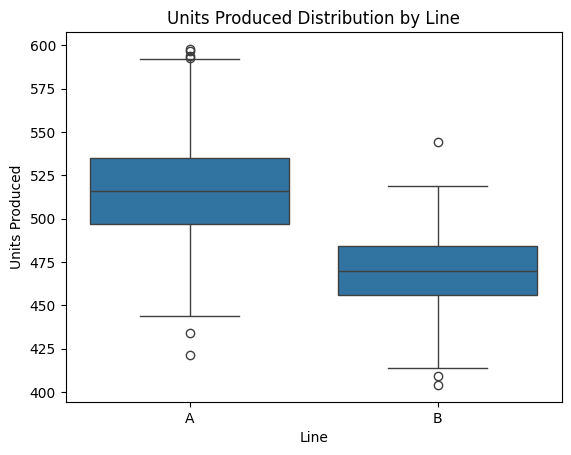

In [ ]:
import seaborn as sns

# Grouped mean
grouped_mean = df.groupby('Line')['Units_Produced'].mean()
print(grouped_mean)

# Boxplot
sns.boxplot(x='Line', y='Units_Produced', data=df)
plt.xlabel('Line')
plt.ylabel('Units Produced')
plt.title('Units Produced Distribution by Line')
plt.show()

* ## There are a lot of fluctuations in the units produced in the production line (seasonal pattern?)
* ## Line A produces more units than line B

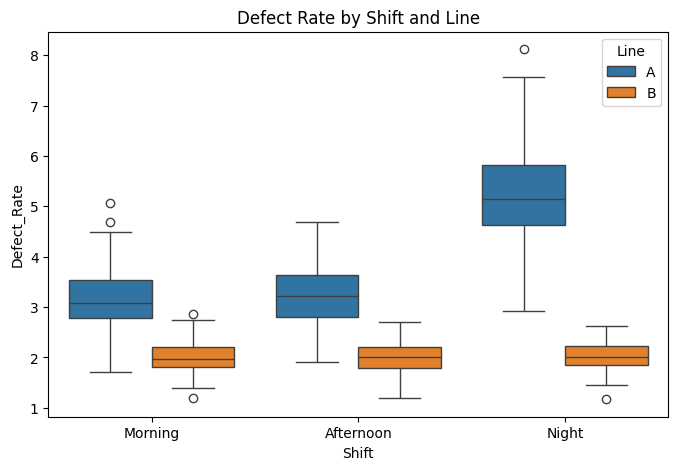

In [ ]:
# Defect rate by shift and line
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Shift", y="Defect_Rate", hue="Line")
plt.title("Defect Rate by Shift and Line")
plt.show()

* ## The line A tends to have higher defect rate than line B, across all shifts
* ## The defect rate is more or less stable/constant during the morning and afternoon shift for Line A. However, the defect rate is much higher in the night shift for Line A
* ## The defect rate is constant across 3 shifts

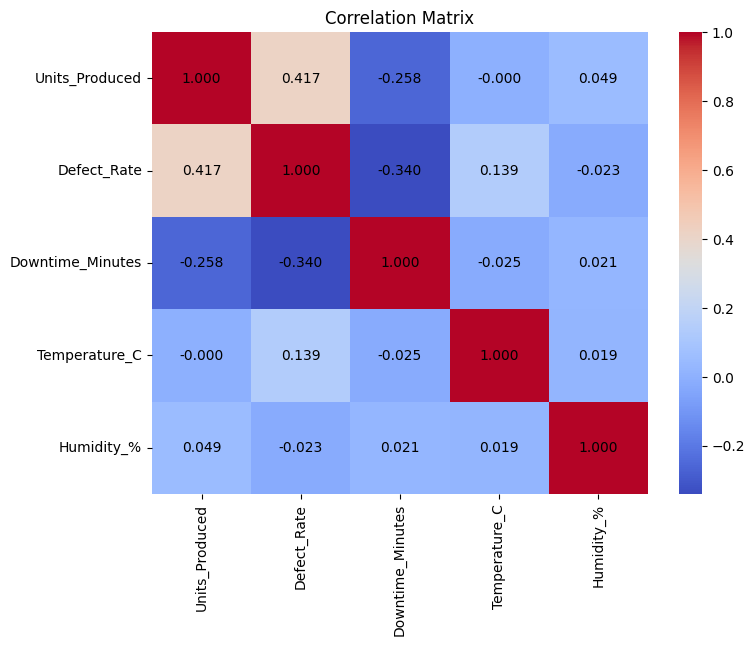

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Units_Produced','Defect_Rate','Downtime_Minutes','Temperature_C','Humidity_%']].corr(), cmap="coolwarm", annot=True, fmt=".3f", annot_kws={"color": "black"})
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df[['Units_Produced','Defect_Rate','Downtime_Minutes','Temperature_C','Humidity_%']].corr()

,Units_Produced,Defect_Rate,Downtime_Minutes,Temperature_C,Humidity_%
Units_Produced,1.000000,0.417173,-0.257513,-0.000343,0.048964
Defect_Rate,0.417173,1.000000,-0.340375,0.139246,-0.023188
Downtime_Minutes,-0.257513,-0.340375,1.000000,-0.025157,0.021015
Temperature_C,-0.000343,0.139246,-0.025157,1.000000,0.019405
Humidity_%,0.048964,-0.023188,0.021015,0.019405,1.000000


* ## The most significant correlation is between 'defect rate' and 'units produced', which is 0.419243. That means, the more units produced, the higher the defect rate. Need to balance the speed and quality in production.
* ## The second most significant correlation is between 'downtime minutes' and 'units produced'. It is negatively correlated which makes sense.
* ## Temperature and humidity seem to be strongly correlated with defect rate and units produced.

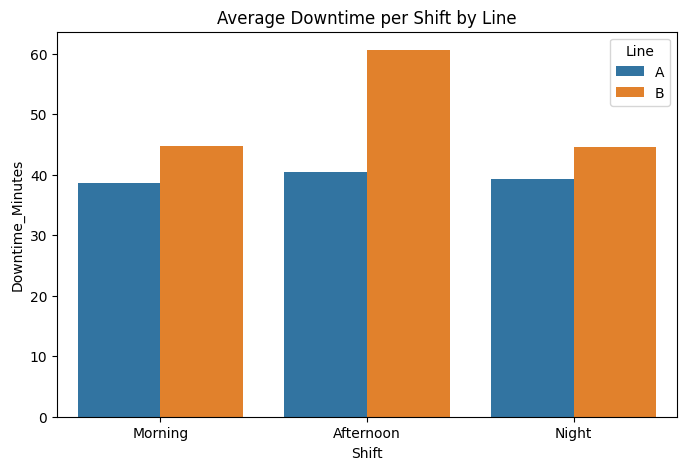

In [ ]:
# Average downtime per shift
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Shift", y="Downtime_Minutes", hue="Line", errorbar=None)
plt.title("Average Downtime per Shift by Line")
plt.show()

* Line B tends to have higher downtime, as compared to line A. Since downtime is negatively correlated with units produced, this might explain why line B tends to have less units produced